In [1]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

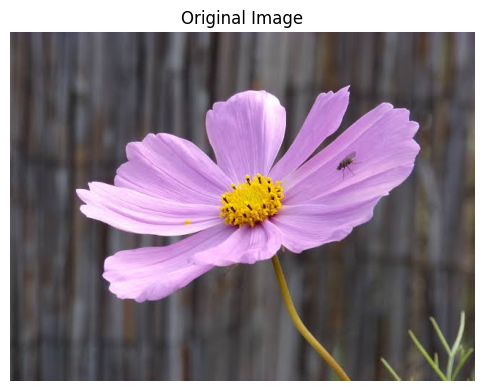

In [2]:
image_path = r"E:\Open CV\Module 14 - Feature Detection\Images\sample.jpg"

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("Image not found!")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

### Harris Corner Detection

## Mathematical Idea

Image gradients are calculated:

Ix

Iy

Then Harris Matrix is computed:

M

Corner response:

R = det(M) − k(trace(M))²

where

k ≈ 0.04–0.06

Large positive R

→ Corner

Small R

→ Flat

Negative R

→ Edge

---

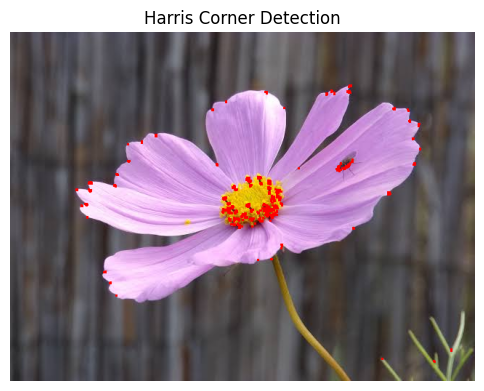

In [ ]:
harris = image_rgb.copy()

gray_float = np.float32(gray)

corners = cv2.cornerHarris(
    gray_float,                   # Input image (grayscale, float32)
    blockSize=2,                  # Size of the neighborhood considered for corner detection
    ksize=3,                      # Aperture parameter for the Sobel operator (used to compute image gradients)
    k=0.04                        # Harris detector free parameter (sensitivity to corners)
)

corners = cv2.dilate(corners, None)

harris[corners > 0.01 * corners.max()] = [255, 0, 0]

plt.figure(figsize=(6,6))
plt.imshow(harris)
plt.title("Harris Corner Detection")
plt.axis("off")
plt.show()

### Shi-Tomasi Corner Detection

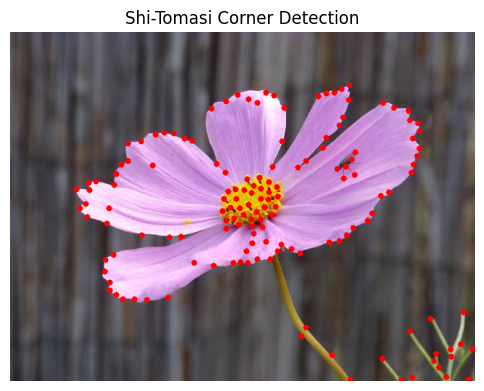

In [ ]:
shi = image_rgb.copy()

corners = cv2.goodFeaturesToTrack(
    gray,                                  # Input image (grayscale)
    maxCorners=150,                        # Maximum number of corners to return
    qualityLevel=0.01,                     # Minimum accepted quality of image corners
    minDistance=10                         # Minimum distance between corners
)

corners = np.int32(corners)

for c in corners:
    x, y = c.ravel()
    cv2.circle(shi, (x, y), 4, (255, 0, 0), -1)

plt.figure(figsize=(6,6))
plt.imshow(shi)
plt.title("Shi-Tomasi Corner Detection")
plt.axis("off")
plt.show()

### FAST Feature Detection

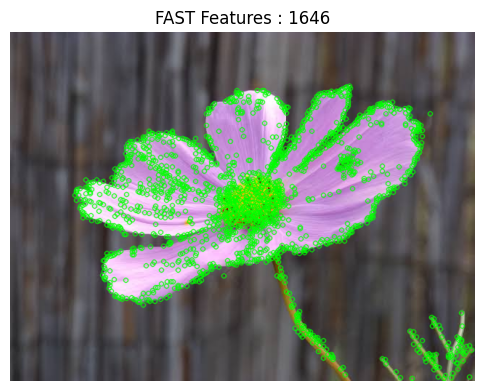

In [5]:
fast = cv2.FastFeatureDetector_create()

kp = fast.detect(gray, None)

fast_img = cv2.drawKeypoints( 
    image_rgb,                           # Input image (RGB)
    kp,                                  # Keypoints detected by the FAST algorithm
    None,                                # Output image (if None, a new image is created)
    color=(0,255,0)                      # Color of the keypoints (green in this case)
)

plt.figure(figsize=(6,6))
plt.imshow(fast_img)
plt.title(f"FAST Features : {len(kp)}")
plt.axis("off")
plt.show()

### ORB Feature Detection

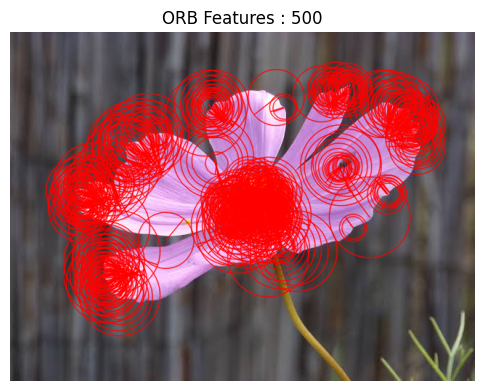

In [ ]:
orb = cv2.ORB_create(nfeatures=500)

kp, des = orb.detectAndCompute(gray, None)

orb_img = cv2.drawKeypoints(
    image_rgb,                                                      # Input image (RGB)
    kp,                                                             # Keypoints detected by the ORB algorithm
    None,                                                           # Output image (if None, a new image is created)
    color=(255,0,0),                                                # Color of the keypoints (blue in this case)
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS                # Flags for drawing the keypoints
)

plt.figure(figsize=(6,6))
plt.imshow(orb_img)
plt.title(f"ORB Features : {len(kp)}")
plt.axis("off")
plt.show()

### SIFT Feature Detection

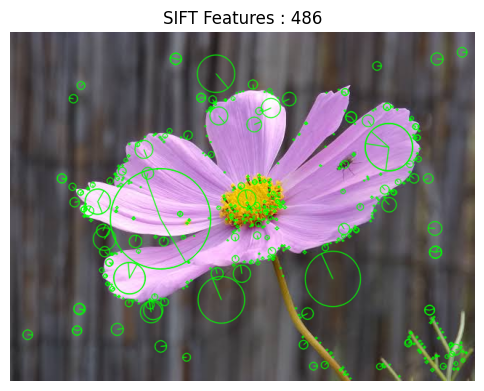

In [ ]:
sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray, None)

sift_img = cv2.drawKeypoints(
    image_rgb,                                                      # Input image (RGB)
    kp,                                                             # Keypoints detected by the SIFT algorithm
    None,                                                           # Output image (if None, a new image is created)
    color=(0,255,0),                                                # Color of the keypoints (green in this case)
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS                # Flags for drawing the keypoints
)

plt.figure(figsize=(6,6))
plt.imshow(sift_img)
plt.title(f"SIFT Features : {len(kp)}")
plt.axis("off")
plt.show()

### SURF Feature Detection

Note: SURF is available only if OpenCV is built with the opencv-contrib package and non-free modules enabled.

In [8]:
try:
    surf = cv2.xfeatures2d.SURF_create(400)

    kp, des = surf.detectAndCompute(gray, None)

    surf_img = cv2.drawKeypoints(
        image_rgb,
        kp,
        None,
        color=(255,0,0),
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    plt.figure(figsize=(6,6))
    plt.imshow(surf_img)
    plt.title(f"SURF Features : {len(kp)}")
    plt.axis("off")
    plt.show()

except:
    print("SURF is not available in your OpenCV installation.")

SURF is not available in your OpenCV installation.


### Comparison of All Algorithms

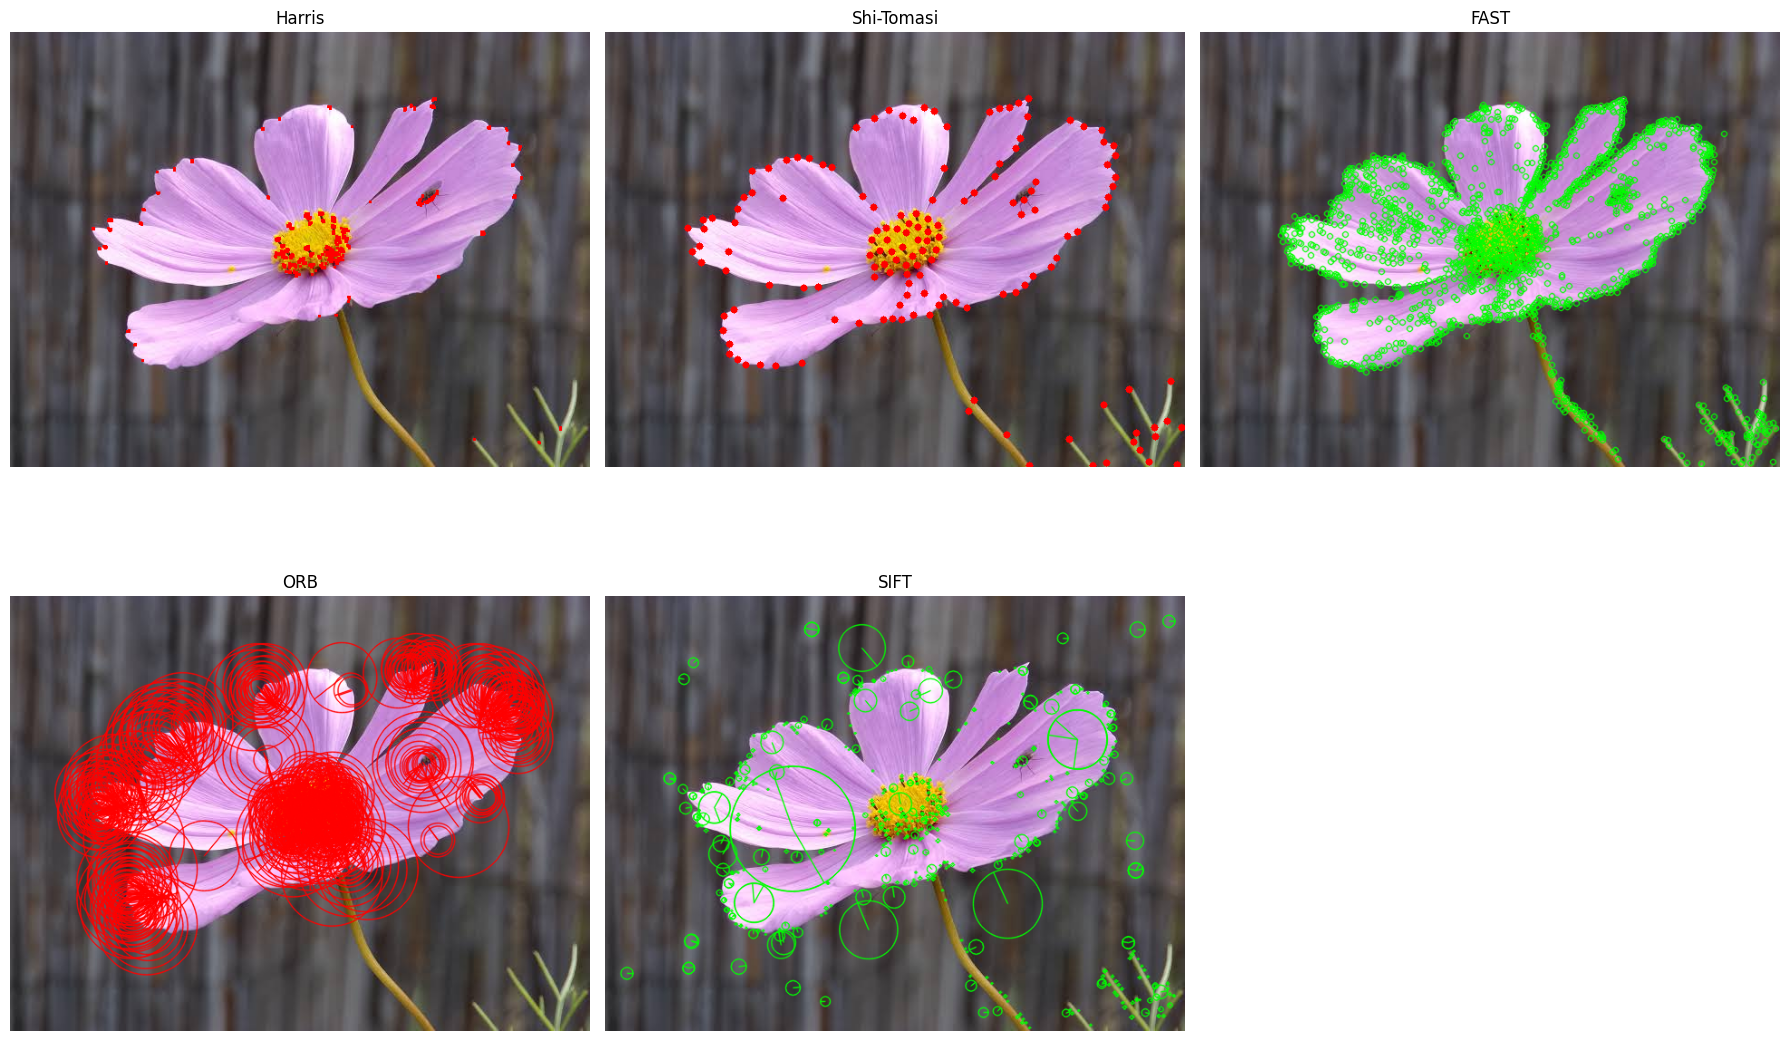

In [10]:
fig = plt.figure(figsize=(18,12))

# Harris
plt.subplot(2,3,1)
plt.imshow(harris)
plt.title("Harris")
plt.axis("off")

# Shi-Tomasi
plt.subplot(2,3,2)
plt.imshow(shi)
plt.title("Shi-Tomasi")
plt.axis("off")

# FAST
plt.subplot(2,3,3)
plt.imshow(fast_img)
plt.title("FAST")
plt.axis("off")

# ORB
plt.subplot(2,3,4)
plt.imshow(orb_img)
plt.title("ORB")
plt.axis("off")

# SIFT
plt.subplot(2,3,5)
plt.imshow(sift_img)
plt.title("SIFT")
plt.axis("off")


plt.tight_layout()
plt.show()

In [13]:
print("FAST Features  :", len(fast.detect(gray, None)))
print("ORB Features   :", len(orb.detect(gray, None)))
print("SIFT Features  :", len(sift.detect(gray, None)))

try:
    print("SURF Features  :", len(surf.detect(gray, None)))
except:
    print("SURF : Not Available")

FAST Features  : 1646
ORB Features   : 500
SIFT Features  : 486
SURF : Not Available
